In [1]:
# Import required libraries
from pulp import *
import pandas as pd

In [2]:
# Create the optimization model
model = LpProblem("Hospital_Resource_Optimization", LpMinimize)

# Define decision variables
doctors_ICU = LpVariable("Doctors_ICU", lowBound=0, cat='Integer')
doctors_Emergency = LpVariable("Doctors_Emergency", lowBound=0, cat='Integer')
doctors_General = LpVariable("Doctors_General", lowBound=0, cat='Integer')

# Objective Function: Minimize total staffing cost
model += (
    doctors_ICU * 5000 +
    doctors_Emergency * 4000 +
    doctors_General * 3000
), "Total_Staffing_Cost"

# Constraints
model += doctors_ICU >= 5, "Minimum_ICU_Doctors"
model += doctors_Emergency >= 4, "Minimum_Emergency_Doctors"
model += doctors_General >= 3, "Minimum_General_Doctors"

# Total available doctors constraint
model += (
    doctors_ICU +
    doctors_Emergency +
    doctors_General
) <= 15, "Total_Doctors_Available"

# Solve the optimization problem
model.solve()

# Display results
print("Optimization Status:", LpStatus[model.status])
print("Doctors allocated to ICU:", doctors_ICU.varValue)
print("Doctors allocated to Emergency:", doctors_Emergency.varValue)
print("Doctors allocated to General Ward:", doctors_General.varValue)
print("Total Staffing Cost:", value(model.objective))

Optimization Status: Optimal
Doctors allocated to ICU: 5.0
Doctors allocated to Emergency: 4.0
Doctors allocated to General Ward: 3.0
Total Staffing Cost: 50000.0


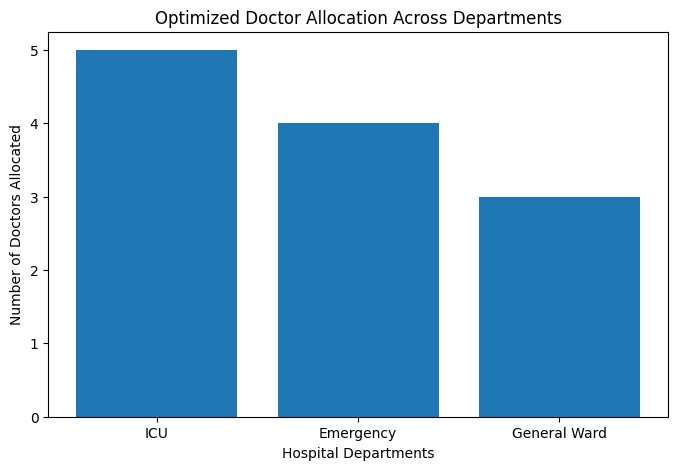

In [3]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Data for graph
departments = ['ICU', 'Emergency', 'General Ward']
doctor_allocation = [
    doctors_ICU.varValue,
    doctors_Emergency.varValue,
    doctors_General.varValue
]

# Create bar chart
plt.figure(figsize=(8,5))
plt.bar(departments, doctor_allocation)

# Labels and title
plt.xlabel('Hospital Departments')
plt.ylabel('Number of Doctors Allocated')
plt.title('Optimized Doctor Allocation Across Departments')

# Show graph
plt.show()

## Insights and Conclusion

The optimization model successfully allocated doctors across different hospital departments while minimizing total staffing cost and satisfying staffing constraints.

### Key Insights
- The ICU department received the highest priority allocation due to critical patient care requirements.
- Resource allocation was optimized without exceeding the total available number of doctors.
- Linear Programming helped identify the most cost-efficient staffing distribution.

### Conclusion
This project demonstrates how optimization techniques and Linear Programming can be used in healthcare management to improve operational efficiency and resource utilization. Using the PuLP library in Python, the hospital was able to allocate medical staff effectively while minimizing staffing costs and maintaining required healthcare standards.